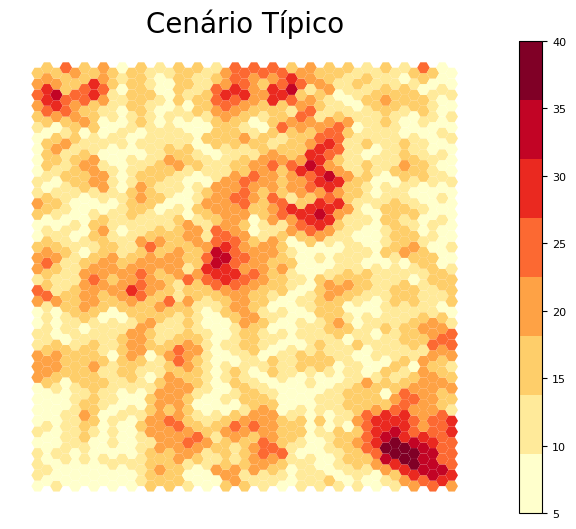

In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from noise import pnoise2

# 1. Função para criar uma malha hexagonal
def hex_grid(xmin, xmax, ymin, ymax, hex_size):
    """Gera uma lista de polígonos hexagonais cobrindo a área especificada."""
    dx = 3/2 * hex_size
    dy = np.sqrt(3) * hex_size
    polys = []
    centers = []
    q = 0
    for x in np.arange(xmin, xmax, dx):
        r = 0
        for y in np.arange(ymin, ymax, dy):
            # Alterna linhas ímpares para formar padrão hexagonal
            cx = x
            cy = y + (np.sqrt(3)/2 * hex_size if q % 2 else 0)
            # Coordenadas do hexágono
            points = [(cx + hex_size * np.cos(np.pi/3*i), 
                       cy + hex_size * np.sin(np.pi/3*i)) for i in range(6)]
            polys.append(Polygon(points))
            centers.append((cx, cy))
            r += 1
        q += 1
    return polys, centers

# 2. Parâmetros da grade
xmin, xmax, ymin, ymax = 0, 10, 0, 10    # Área de 10x10
hex_size = .15                           # Tamanho do hexágono

polys, centers = hex_grid(xmin, xmax, ymin, ymax, hex_size)
gdf = gpd.GeoDataFrame(geometry=polys)

# 3. Função de acessibilidade realista: Formigueiro (rede de túneis/clusters orgânicos)
def accessibility_func(x, y, agravamento=0.0):
    # --- CAMADA 1: A Geografia da Cidade 
    scale_cidade = 2
    perlin_cidade = pnoise2(x/scale_cidade, y/scale_cidade, octaves=4, persistence=0.5, lacunarity=2.0, repeatx=100, repeaty=100, base=42)
    
    tunel_network = abs(perlin_cidade)
    
    tunel_suave = np.power(tunel_network, 0.75) 

    # --- CAMADA 2: Onde a perturbação ocorre ---
    if agravamento > 0:
        scale_evento = 4
        # Offset na base para desenhar manchas bem separadas da geometria da cidade
        perlin_evento = pnoise2(x/scale_evento, y/scale_evento, octaves=2, repeatx=100, repeaty=100, base=99)
        
        # Se o ruído não for suficientemente forte (>= 0.1), ele zera abruptamente.
        if perlin_evento > 0.1:
            mancha_evento = np.clip((perlin_evento - 0.1) * 3, 0, 1)
        else:
            mancha_evento = 0.0
    else:
        mancha_evento = 0.0
    
    base_tempo = 5 + (agravamento * 15 * mancha_evento)
    multiplicador = 40 + (agravamento * 60 * mancha_evento)  
    
    valor = base_tempo + multiplicador * tunel_suave
    
    return valor

# 0.0 = Nenhum desastre (Apenas o mapa puro)
# 1.0 = Evento atingindo partes da cidade (Mantém as rotas, mas penaliza o tempo)
nivel_agravamento = 0.5

# 4. Aplicando função de acessibilidade
gdf["cx"] = [c[0] for c in centers]
gdf["cy"] = [c[1] for c in centers]
gdf["tempo_acesso"] = gdf.apply(lambda r: accessibility_func(r.cx, r.cy, agravamento=nivel_agravamento), axis=1)

# 5. Plot e exportação JPG
px_width = 820
px_height = 540
dpi = 100

fig, ax = plt.subplots(figsize=(px_width / dpi, px_height / dpi), dpi=dpi)

cmap = plt.get_cmap("YlOrRd", 8)
gdf.plot(column="tempo_acesso", ax=ax, edgecolor="none", cmap=cmap, legend=True, vmin=5, vmax=40)

try:
    cax = fig.axes[1]
    cax.tick_params(labelsize=8)
except IndexError:
    pass

ax.set_axis_off()
desc_cenario = "Típico" if nivel_agravamento < 1 else "Condicionado"
ax.set_title(f"Cenário {desc_cenario}", fontsize=20)

plt.tight_layout()
plt.savefig(f"malha_hex_acessibilidade_{desc_cenario}.jpg", dpi=dpi, bbox_inches="tight")

plt.show()